# Ch10 觀測器入門(Introduction to Observers)

**對應原書**:Chapter 10
**軟體替代**:ModelQ 觀測器方塊 → NumPy 手寫離散 Luenberger 觀測器 + `control.place` 極點配置

## 學習目標
1. 建立 Luenberger 觀測器結構:**模型預測 + 量測修正**。
   $$\dot{\hat{x}} = A\hat{x} + Bu + L(y - C\hat{x})$$
2. 用極點配置設計觀測器增益 L。
3. 體會觀測器的核心價值:從**位置量測**重建**乾淨的速度**。

## 系統
馬達位置系統:狀態 $x = [\theta, \omega]^T$,輸入轉矩,量測只有位置。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

In [2]:
J, b = 0.002, 0.01
A = np.array([[0.0, 1.0], [0.0, -b / J]])
B = np.array([[0.0], [1.0 / J]])
Cm = np.array([[1.0, 0.0]])

print('可觀測性矩陣秩 =', np.linalg.matrix_rank(ct.obsv(A, Cm)))

# 觀測器極點:比預期迴路頻寬(~40 Hz ≈ 250 rad/s)稍快
obs_poles = [-200, -220]
L = np.asarray(ct.place(A.T, Cm.T, obs_poles)).T
print('觀測器增益 L =', L.ravel())
print('驗證極點:', np.linalg.eigvals(A - L @ Cm))

可觀測性矩陣秩 = 2
觀測器增益 L = [  415. 41925.]
驗證極點: [-220.+0.j -200.+0.j]


## 觀測器收斂實驗

開迴路施加正弦轉矩,觀測器初始速度估測故意設錯(-2 rad/s),看它多快收斂。

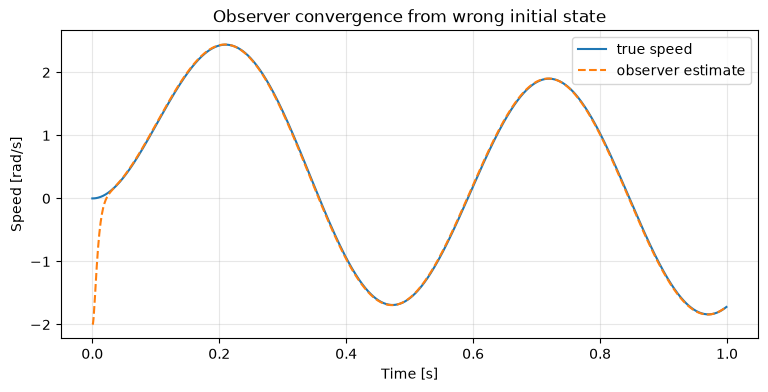

初始速度誤差 2.00 → 後半段最大誤差 0.02224


In [3]:
fs = 1000.0
dt = 1 / fs
n = int(1.0 / dt)
t = np.arange(n) * dt
u_torque = 0.05 * np.sin(2 * np.pi * 2 * t)

plant = MotorPlant(J=J, b=b, dt=dt)
xhat = np.array([0.0, -2.0])           # 故意給錯的初始估測
w_true, w_hat = np.empty(n), np.empty(n)
for k in range(n):
    w_true[k] = plant.w
    w_hat[k] = xhat[1]
    y_meas = plant.pos                  # 只量位置
    innov = y_meas - Cm @ xhat
    xhat = xhat + (A @ xhat + B.ravel() * u_torque[k] + L.ravel() * innov) * dt
    plant.step(u_torque[k])

plt.figure(figsize=(9, 4))
plt.plot(t, w_true, label='true speed')
plt.plot(t, w_hat, '--', label='observer estimate')
plt.xlabel('Time [s]'); plt.ylabel('Speed [rad/s]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Observer convergence from wrong initial state')
plt.show()
err_early = float(abs(w_true[0] - w_hat[0]))
err_late = float(np.max(np.abs(w_true[n//2:] - w_hat[n//2:])))
print(f'初始速度誤差 {err_early:.2f} → 後半段最大誤差 {err_late:.5f}')

## 觀測器 vs 差分:量測有量化時

實務位置來自編碼器(有量化)。比較兩種取得速度的方式:
1. **有限差分**:$(y_k - y_{k-1})/T_s$ —— 量化雜訊被放大 $q/T_s$。
2. **觀測器**:雜訊被觀測器頻寬濾掉,而且沒有差分的半拍延遲。

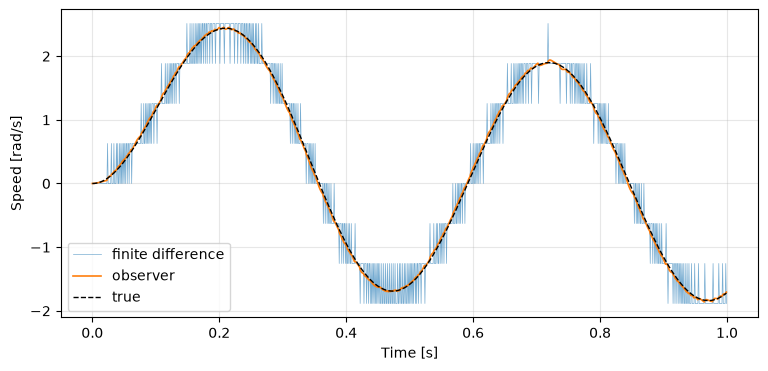

速度誤差 RMS:差分 0.2574 | 觀測器 0.0321(改善 8.0 倍)
差分雜訊理論值 ~ q/(sqrt(6)·Ts) = 0.2565


In [4]:
enc = EncoderModel(lines=2500)          # 10000 counts/rev,q=2π/10000 rad
q_rad = 2 * np.pi / enc.counts_per_rev

plant = MotorPlant(J=J, b=b, dt=dt)
xhat = np.zeros(2)
prev_y = 0.0
w_true2, w_fd, w_obs = np.empty(n), np.empty(n), np.empty(n)
for k in range(n):
    w_true2[k] = plant.w
    y_meas = float(enc.read(plant.pos / (2 * np.pi))) * 2 * np.pi   # 量化位置 [rad]
    w_fd[k] = (y_meas - prev_y) / dt
    prev_y = y_meas
    innov = y_meas - Cm @ xhat
    xhat = xhat + (A @ xhat + B.ravel() * u_torque[k] + L.ravel() * innov) * dt
    w_obs[k] = xhat[1]
    plant.step(u_torque[k])

plt.figure(figsize=(9, 4))
plt.plot(t, w_fd, lw=0.5, alpha=0.6, label='finite difference')
plt.plot(t, w_obs, lw=1.2, label='observer')
plt.plot(t, w_true2, 'k--', lw=1, label='true')
plt.xlabel('Time [s]'); plt.ylabel('Speed [rad/s]'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

noise_fd = float(np.std(w_fd[200:] - w_true2[200:]))
noise_obs = float(np.std(w_obs[200:] - w_true2[200:]))
print(f'速度誤差 RMS:差分 {noise_fd:.4f} | 觀測器 {noise_obs:.4f}(改善 {noise_fd/noise_obs:.1f} 倍)')
print(f'差分雜訊理論值 ~ q/(sqrt(6)·Ts) = {q_rad / np.sqrt(6) / dt:.4f}')

In [5]:
# ✅ 驗證
poles_achieved = np.sort(np.linalg.eigvals(A - L @ Cm).real)
assert np.allclose(poles_achieved, sorted(obs_poles), rtol=1e-6)
assert err_early > 1.5 and err_late < 0.05        # 從大誤差收斂(殘差為 Euler 離散化誤差)
assert noise_obs < noise_fd / 3                   # 觀測器速度乾淨得多
assert noise_fd > q_rad / dt / 10                 # 差分雜訊量級與理論一致
print('Ch10 驗證通過 ✅')

Ch10 驗證通過 ✅


## 練習
1. 觀測器極點放到 -50/-60(太慢)與 -2000/-2200(太快),分別發生什麼事?
2. 給觀測器的模型慣量故意錯 +50%,速度估測出現什麼系統性誤差?
3. 在轉矩路徑加入未知常值負載,估測會偏移 —— 擴充狀態(加一個負載轉矩狀態)解決它。
4. 把觀測器嵌入速度閉迴路(用 w_obs 回授),與差分回授比較可用的最大 kp(第 18 章預告)。